# Correlação e Regressão Linear

Até aqui, cada módulo tratou uma variável de cada vez. Este módulo estuda a **relação
entre duas variáveis**: primeiro mede essa relação (covariância, correlação) e depois a
modela (regressão linear simples) — a ponte direta para
[Econometria I](../07_Econometria_I).

Pré-requisito: [Módulo 04 — Inferência Estatística](../04_Inferência_Estatística)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({'font.size': 12})
sns.set_theme(style='whitegrid')

## 1. Distribuição conjunta de duas variáveis

Quando duas variáveis aleatórias discretas $X$ e $Y$ são observadas juntas, sua
**distribuição conjunta** $p(x,y) = P(X=x, Y=y)$ carrega mais informação do que as duas
distribuições marginais separadas — inclusive se $X$ e $Y$ têm alguma relação entre si.

### Exemplo — tabela de distribuição conjunta

$$
\begin{array}{c|ccc}
 & X=1 & X=2 & X=3 \\\hline
Y=0 & 0{,}10 & 0{,}10 & 0{,}10 \\
Y=1 & 0{,}20 & 0{,}00 & 0{,}30 \\
Y=2 & 0{,}00 & 0{,}10 & 0{,}10
\end{array}
$$

In [2]:
x_vals = np.array([1, 2, 3])
y_vals = np.array([0, 1, 2])

# p[i, j] = P(Y = y_vals[i], X = x_vals[j])
p = np.array([
    [0.10, 0.10, 0.10],
    [0.20, 0.00, 0.30],
    [0.00, 0.10, 0.10],
])

print("Soma de todas as probabilidades:", p.sum())  # tem que dar 1.0

# Distribuições marginais: somar sobre a outra variável
p_x = p.sum(axis=0)  # marginal de X: soma por coluna
p_y = p.sum(axis=1)  # marginal de Y: soma por linha

print("P(X):", dict(zip(x_vals, p_x)))
print("P(Y):", dict(zip(y_vals, p_y)))

Soma de todas as probabilidades: 1.0
P(X): {np.int64(1): np.float64(0.30000000000000004), np.int64(2): np.float64(0.2), np.int64(3): np.float64(0.5)}
P(Y): {np.int64(0): np.float64(0.30000000000000004), np.int64(1): np.float64(0.5), np.int64(2): np.float64(0.2)}


## 2. Covariância

A covariância mede se duas variáveis tendem a variar **juntas** (positiva), **em sentidos
opostos** (negativa), ou sem padrão linear discernível (perto de zero):

$$Cov(X,Y) = E(XY) - E(X)\,E(Y)$$

Calculando a partir da tabela conjunta acima:

In [3]:
E_X = np.sum(x_vals * p_x)
E_Y = np.sum(y_vals * p_y)

# E(XY) = soma de x*y*p(x,y) para todas as combinações
E_XY = np.sum(x_vals[None, :] * y_vals[:, None] * p)

cov_XY = E_XY - E_X * E_Y

print(f"E(X)  = {E_X:.2f}")
print(f"E(Y)  = {E_Y:.2f}")
print(f"E(XY) = {E_XY:.2f}")
print(f"Cov(X,Y) = {cov_XY:.4f}")

E(X)  = 2.20
E(Y)  = 0.90
E(XY) = 2.10
Cov(X,Y) = 0.1200


Covariância positiva: quando $X$ tende a ser maior, $Y$ também tende a ser maior (e
vice-versa) — nesta tabela, a "massa" de probabilidade está deslocada para
combinações onde ambas crescem ou ambas ficam baixas juntas.

O problema da covariância é que sua **escala depende das unidades** de $X$ e $Y$ — não dá
para comparar a força de duas relações diferentes só olhando o valor bruto. É para isso
que serve o coeficiente de correlação.

## 3. Coeficiente de correlação de Pearson

Normaliza a covariância pelo produto dos desvios padrão, sempre entre $-1$ e $+1$:

$$r = \frac{Cov(X,Y)}{\sigma_X\,\sigma_Y}$$

$r=+1$: correlação linear perfeita positiva · $r=-1$: perfeita negativa · $r=0$: nenhuma
correlação linear (pode ainda haver relação não-linear!) · $|r|\geq 0{,}7$ costuma ser
lido como correlação forte.

### Exemplo — preço x volume de vendas

Uma pesquisa de mercado sobre um componente eletrônico, vendido a preços diferentes em
lojas diferentes, registrou o preço (X, em u.m.) e o número de unidades vendidas por mês
(Y) em cada loja.

In [4]:
preco = np.array([0.05, 0.12, 0.17, 0.25, 0.30, 0.32, 0.38])
vendas = np.array([7.1, 9.6, 16.9, 25.4, 28.1, 35.7, 39.0])

r, p_valor = stats.pearsonr(preco, vendas)
cov_manual = np.cov(preco, vendas, ddof=1)[0, 1]

print(f"covariância amostral = {cov_manual:.4f}")
print(f"r de Pearson         = {r:.4f}")
print(f"p-valor               = {p_valor:.4f}")

covariância amostral = 1.4420
r de Pearson         = 0.9853
p-valor               = 0.0000


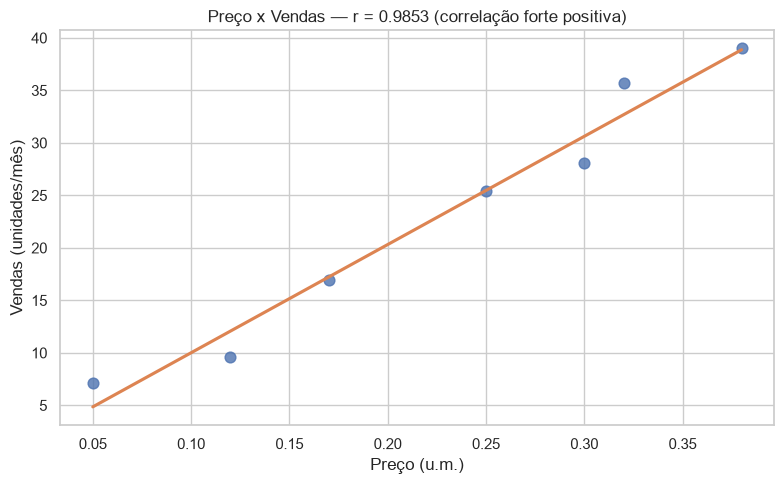

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x=preco, y=vendas, ax=ax, ci=None,
            scatter_kws={'color': '#4C72B0', 's': 60},
            line_kws={'color': '#DD8452'})
ax.set_title(f'Preço x Vendas — r = {r:.4f} (correlação forte positiva)')
ax.set_xlabel('Preço (u.m.)')
ax.set_ylabel('Vendas (unidades/mês)')
plt.tight_layout()
plt.savefig('img_correlacao_preco_vendas.png', dpi=110)
plt.show()

**Correlação não implica causalidade** — o preço mais alto não *causa* mais vendas;
o mais provável é que ambos reflitam um terceiro fator (ex: componentes de melhor
qualidade custam mais caro e vendem mais). $r$ mede associação linear, não mecanismo.

## 4. Regressão linear simples (Método dos Mínimos Quadrados)

Enquanto a correlação só mede a força da relação, a regressão a **modela**: encontra a
reta $\hat{y} = a + bx$ que minimiza a soma dos quadrados dos resíduos
($\sum (y_i - \hat{y}_i)^2$) — daí "Mínimos Quadrados Ordinários" (MQO/OLS).

$$b = \frac{Cov(X,Y)}{Var(X)} \qquad\qquad a = \bar{y} - b\bar{x}$$

Ajustando aos dados de preço x vendas:

In [6]:
X_const = sm.add_constant(preco)          # adiciona o intercepto (a)
modelo = sm.OLS(vendas, X_const).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     166.8
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           4.96e-05
Time:                        02:12:45   Log-Likelihood:                -14.622
No. Observations:                   7   AIC:                             33.24
Df Residuals:                       5   BIC:                             33.14
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2981      2.012     -0.148      0.8

C:\Users\allan\Documents\Projects\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [7]:
a, b = modelo.params
print(f"Equação ajustada: vendas = {a:.2f} + {b:.2f} × preço")
print(f"R² = {modelo.rsquared:.4f}")

# Interpretação prática do coeficiente angular
print(f"\nA cada 0,10 u.m. de aumento no preço, o modelo prevê "
      f"{b * 0.10:.2f} unidades a mais de venda por mês.")

Equação ajustada: vendas = -0.30 + 103.07 × preço
R² = 0.9709

A cada 0,10 u.m. de aumento no preço, o modelo prevê 10.31 unidades a mais de venda por mês.


## 5. Coeficiente de determinação (R²)

$$R^2 = \frac{\text{variância explicada pelo modelo}}{\text{variância total de } Y} = r^2 \text{ (na regressão simples)}$$

$R^2$ vai de 0 a 1 e diz **que fração da variação de $Y$ o modelo consegue explicar**. Em
regressão linear simples, $R^2$ é exatamente o quadrado do $r$ de Pearson — não é
coincidência, são a mesma informação vista de dois ângulos.

### Contraste — quando a relação é fraca

Nem toda relação entre duas variáveis é assim tão limpa. Nestes outros dados (mesmo
método, contexto diferente), a correlação é bem mais fraca:

In [8]:
x_fraco = np.array([10, 20, 30, 40, 50])
y_fraco = np.array([120, 110, 130, 105, 150])

r_fraco, _ = stats.pearsonr(x_fraco, y_fraco)
modelo_fraco = sm.OLS(y_fraco, sm.add_constant(x_fraco)).fit()

print(f"r  = {r_fraco:.4f}")
print(f"R² = {modelo_fraco.rsquared:.4f}")
print(f"Equação: y = {modelo_fraco.params[0]:.2f} + {modelo_fraco.params[1]:.4f}x")

r  = 0.4861
R² = 0.2363
Equação: y = 106.50 + 0.5500x


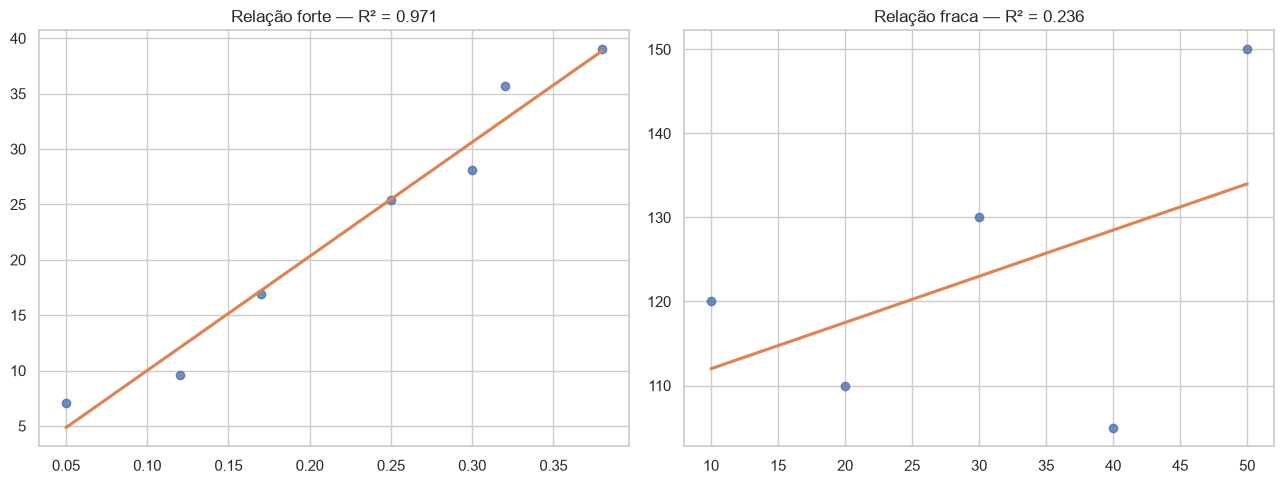

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(x=preco, y=vendas, ax=axes[0], ci=None,
            scatter_kws={'color': '#4C72B0'}, line_kws={'color': '#DD8452'})
axes[0].set_title(f'Relação forte — R² = {modelo.rsquared:.3f}')

sns.regplot(x=x_fraco, y=y_fraco, ax=axes[1], ci=None,
            scatter_kws={'color': '#4C72B0'}, line_kws={'color': '#DD8452'})
axes[1].set_title(f'Relação fraca — R² = {modelo_fraco.rsquared:.3f}')

plt.tight_layout()
plt.savefig('img_comparacao_r2.png', dpi=110)
plt.show()

## 6. Análise gráfica de resíduos

O resíduo de cada ponto é $e_i = y_i - \hat{y}_i$ — o que o modelo **não** conseguiu
explicar. Olhar o gráfico de resíduos (contra os valores previstos) é o jeito mais rápido
de flagrar problemas: se os pontos estiverem espalhados aleatoriamente ao redor de zero,
o ajuste linear é razoável; se houver um padrão (curva, funil, tendência), o modelo linear
provavelmente não é adequado.

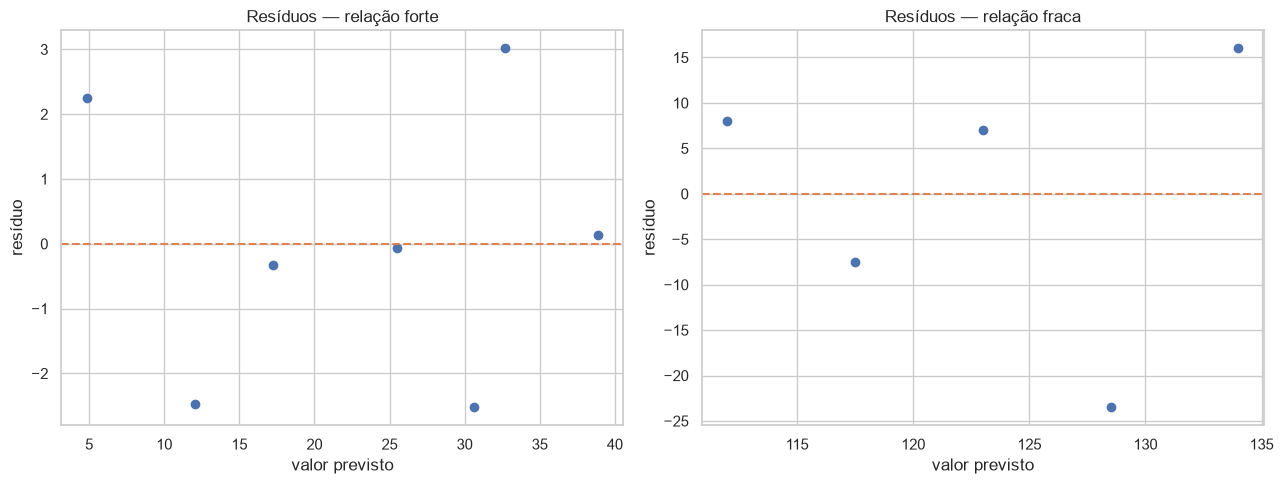

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

previstos_forte = modelo.predict(X_const)
residuos_forte = vendas - previstos_forte
axes[0].scatter(previstos_forte, residuos_forte, color='#4C72B0')
axes[0].axhline(0, color='#DD8452', linestyle='--')
axes[0].set_title('Resíduos — relação forte')
axes[0].set_xlabel('valor previsto')
axes[0].set_ylabel('resíduo')

previstos_fraco = modelo_fraco.predict(sm.add_constant(x_fraco))
residuos_fraco = y_fraco - previstos_fraco
axes[1].scatter(previstos_fraco, residuos_fraco, color='#4C72B0')
axes[1].axhline(0, color='#DD8452', linestyle='--')
axes[1].set_title('Resíduos — relação fraca')
axes[1].set_xlabel('valor previsto')
axes[1].set_ylabel('resíduo')

plt.tight_layout()
plt.savefig('img_analise_residuos.png', dpi=110)
plt.show()

No caso forte, os resíduos são pequenos e sem padrão óbvio — o modelo linear captura
bem a relação. No caso fraco, os resíduos são grandes relativos à escala de $Y$ — sinal de
que uma reta explica pouco da variação, e $R^2$ baixo já era o alerta esperado antes
mesmo de olhar o gráfico.

## 7. Exercícios de fixação

1. Uma pesquisa relacionou horas semanais de estudo (X) e nota final (Y) de 6 alunos:
   X = [2, 4, 5, 7, 8, 10], Y = [50, 58, 63, 75, 80, 90]. Calcule $r$, ajuste uma
   regressão linear e reporte $R^2$.
2. Com o modelo do exercício 1, qual nota o modelo prevê para um aluno que estuda 6 horas
   por semana?

In [11]:
horas = np.array([2, 4, 5, 7, 8, 10])
notas = np.array([50, 58, 63, 75, 80, 90])

r_ex, _ = stats.pearsonr(horas, notas)
modelo_ex = sm.OLS(notas, sm.add_constant(horas)).fit()

print(f"1) r = {r_ex:.4f}   R² = {modelo_ex.rsquared:.4f}")
print(f"   equação: nota = {modelo_ex.params[0]:.2f} + {modelo_ex.params[1]:.2f} x horas")

previsao_6h = modelo_ex.predict([1, 6])[0]
print(f"2) previsão para 6h de estudo: {previsao_6h:.1f}")

1) r = 0.9980   R² = 0.9960
   equação: nota = 38.48 + 5.14 x horas
2) previsão para 6h de estudo: 69.3


## Encerramento do módulo

Com distribuição conjunta, covariância, correlação, regressão MQO, R² e resíduos, o
Módulo 05 está completo — e prepara o terreno para
[Módulo 07 — Econometria I](../07_Econometria_I), onde a regressão simples se generaliza
para múltiplas variáveis explicativas.

## Bibliografia
- TRIOLA, Mario F. *Introdução à Estatística*. 8. ed. Rio de Janeiro: LTC, 2005.
- BUSSAB, Wilton O.; MORETTIN, Pedro A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- WOOLDRIDGE, Jeffrey M. *Introdução à Econometria: uma abordagem moderna*. São Paulo: Cengage Learning, 2016.
- FIELD, Andy. *Descobrindo a Estatística usando o SPSS*. 2. ed. Porto Alegre: Artmed, 2009.